In [1]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\AYUSH\anaconda3\anaconda3ayush\envs\quantum-materials-ml\python.exe
3.11.16 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:36:16) [MSC v.1942 64 bit (AMD64)]


In [2]:
from jarvis.db.figshare import data
import pandas as pd
import numpy as np

print("Loading JARVIS-DFT 3D dataset...")

dft_3d = data("dft_3d")

df = pd.DataFrame(dft_3d)

print("Dataset loaded!")
print("Shape:", df.shape)

Loading JARVIS-DFT 3D dataset...
Obtaining 3D dataset 94k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.
Dataset loaded!
Shape: (93902, 64)


In [3]:
df.head()

,jid,spg_number,spg_symbol,formula,formation_energy_peratom,func,optb88vdw_bandgap,atoms,slme,magmom_oszicar,...,density,poisson,raw_files,nat,bulk_modulus_kv,shear_modulus_gv,mbj_bandgap,hse_gap,reference,search
0,JVASP-90856,129,P4/nmm,TiCuSiAs,-0.42762,OptB88vdW,0.000,"{'lattice_mat': [[3.566933224304235, 0.0, -0.0...",na,0.0,...,5.956,na,[],8,na,na,na,na,mp-1080455,-As-Cu-Si-Ti
1,JVASP-86097,221,Pm-3m,DyB6,-0.41596,OptB88vdW,0.000,"{'lattice_mat': [[4.089078911208881, 0.0, 0.0]...",na,0.0,...,5.522,na,"[OPT-LOPTICS,JVASP-86097.zip,https://ndownload...",7,na,na,na,na,mp-568319,-B-Dy
2,JVASP-64906,119,I-4m2,Be2OsRu,0.04847,OptB88vdW,0.000,"{'lattice_mat': [[-1.833590720595598, 1.833590...",na,0.0,...,10.960,na,"[OPT-LOPTICS,JVASP-64906.zip,https://ndownload...",4,na,na,na,na,auid-3eaf68dd483bf4f4,-Be-Os-Ru
3,JVASP-98225,14,P2_1/c,KBi,-0.44140,OptB88vdW,0.472,"{'lattice_mat': [[7.2963518353359165, 0.0, 0.0...",na,0.0,...,5.145,na,[],32,na,na,na,na,mp-31104,-Bi-K
4,JVASP-10,164,P-3m1,VSe2,-0.71026,OptB88vdW,0.000,"{'lattice_mat': [[1.6777483798834445, -2.90594...",na,0.0,...,5.718,0.23,"[FD-ELAST,JVASP-10.zip,https://ndownloader.fig...",3,48.79,33.05,0.0,na,mp-694,-Se-V


In [4]:
df.columns.tolist()

['jid',
 'spg_number',
 'spg_symbol',
 'formula',
 'formation_energy_peratom',
 'func',
 'optb88vdw_bandgap',
 'atoms',
 'slme',
 'magmom_oszicar',
 'spillage',
 'elastic_tensor',
 'effective_masses_300K',
 'kpoint_length_unit',
 'maxdiff_mesh',
 'maxdiff_bz',
 'encut',
 'optb88vdw_total_energy',
 'epsx',
 'epsy',
 'epsz',
 'mepsx',
 'mepsy',
 'mepsz',
 'modes',
 'magmom_outcar',
 'max_efg',
 'avg_elec_mass',
 'avg_hole_mass',
 'icsd',
 'dfpt_piezo_max_eij',
 'dfpt_piezo_max_dij',
 'dfpt_piezo_max_dielectric',
 'dfpt_piezo_max_dielectric_electronic',
 'dfpt_piezo_max_dielectric_ionic',
 'max_ir_mode',
 'min_ir_mode',
 'n-Seebeck',
 'p-Seebeck',
 'n-powerfact',
 'p-powerfact',
 'ncond',
 'pcond',
 'nkappa',
 'pkappa',
 'ehull',
 'Tc_supercon',
 'dimensionality',
 'efg',
 'xml_data_link',
 'typ',
 'exfoliation_energy',
 'spg',
 'crys',
 'density',
 'poisson',
 'raw_files',
 'nat',
 'bulk_modulus_kv',
 'shear_modulus_gv',
 'mbj_bandgap',
 'hse_gap',
 'reference',
 'search']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 93902 entries, 0 to 93901
Data columns (total 64 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   jid                                   93902 non-null  str    
 1   spg_number                            93902 non-null  str    
 2   spg_symbol                            93902 non-null  str    
 3   formula                               93902 non-null  str    
 4   formation_energy_peratom              93902 non-null  float64
 5   func                                  93902 non-null  str    
 6   optb88vdw_bandgap                     93902 non-null  float64
 7   atoms                                 93902 non-null  object 
 8   slme                                  93902 non-null  object 
 9   magmom_oszicar                        93902 non-null  object 
 10  spillage                              93902 non-null  object 
 11  elastic_tensor            

In [6]:
df["optb88vdw_bandgap"].describe()

count    93902.000000
mean         0.578425
std          1.310606
min          0.000000
25%          0.000000
50%          0.000000
75%          0.243000
max         18.179000
Name: optb88vdw_bandgap, dtype: float64

In [7]:
df["optb88vdw_bandgap"].value_counts(dropna=False).head(20)

optb88vdw_bandgap
0.000    67062
0.001       45
0.002       42
0.005       41
0.035       34
0.004       32
0.003       32
0.030       31
0.033       31
0.006       30
0.008       30
0.013       29
0.011       28
0.052       28
0.014       27
0.012       26
0.025       26
0.015       25
0.016       23
0.024       23
Name: count, dtype: int64

In [8]:
missing = df.isna().sum()

missing = missing.sort_values(ascending=False)

missing.head(20)

jid                         0
spg_number                  0
spg_symbol                  0
formula                     0
formation_energy_peratom    0
func                        0
optb88vdw_bandgap           0
atoms                       0
slme                        0
magmom_oszicar              0
spillage                    0
elastic_tensor              0
effective_masses_300K       0
kpoint_length_unit          0
maxdiff_mesh                0
maxdiff_bz                  0
encut                       0
optb88vdw_total_energy      0
epsx                        0
epsy                        0
dtype: int64

In [9]:
df["optb88vdw_bandgap"].dtype

dtype('float64')

In [10]:
df["optb88vdw_bandgap"].unique()[:20]

array([0.   , 0.472, 0.689, 1.517, 2.122, 0.502, 1.197, 0.56 , 0.051,
       4.907, 1.681, 0.016, 0.658, 2.472, 3.851, 0.482, 0.924, 4.03 ,
       0.239, 1.569])

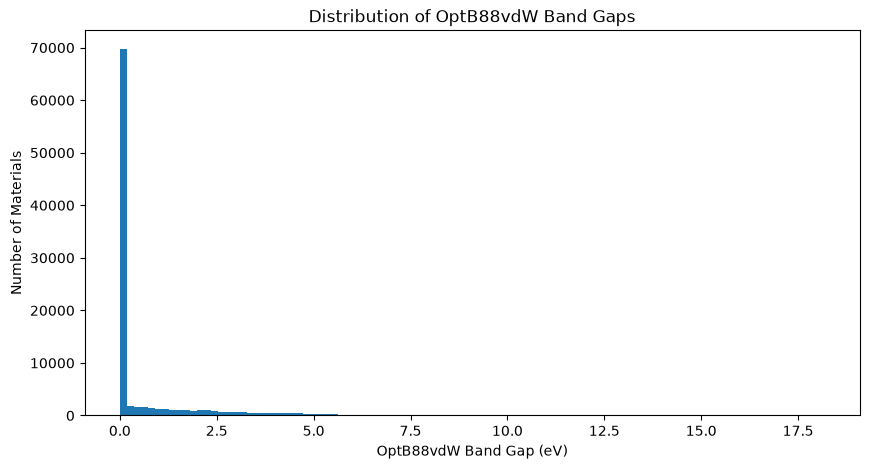

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df["optb88vdw_bandgap"], bins=100)

plt.xlabel("OptB88vdW Band Gap (eV)")
plt.ylabel("Number of Materials")
plt.title("Distribution of OptB88vdW Band Gaps")

plt.show()

In [12]:
print("Zero band-gap materials:",
      (df["optb88vdw_bandgap"] == 0).sum())

print("Non-zero band-gap materials:",
      (df["optb88vdw_bandgap"] > 0).sum())

print("Percentage with zero band gap:",
      (df["optb88vdw_bandgap"] == 0).mean() * 100)

Zero band-gap materials: 67062
Non-zero band-gap materials: 26840
Percentage with zero band gap: 71.41700922238078


In [13]:
# Check missing values in important columns
important_columns = [
    "jid",
    "formula",
    "spg_number",
    "crys",
    "optb88vdw_bandgap"
]

df[important_columns].isna().sum()

jid                  0
formula              0
spg_number           0
crys                 0
optb88vdw_bandgap    0
dtype: int64

In [14]:
# Check whether any important values are stored as strings
for column in important_columns:
    print(f"\n{column}")
    print(df[column].map(type).value_counts())


jid
jid
<class 'str'>    93902
Name: count, dtype: int64

formula
formula
<class 'str'>    93902
Name: count, dtype: int64

spg_number
spg_number
<class 'str'>    93902
Name: count, dtype: int64

crys
crys
<class 'str'>    93902
Name: count, dtype: int64

optb88vdw_bandgap
optb88vdw_bandgap
<class 'float'>    93902
Name: count, dtype: int64


In [15]:
# Check invalid band-gap values
print("Negative band gaps:",
      (df["optb88vdw_bandgap"] < 0).sum())

print("Infinite band gaps:",
      np.isinf(df["optb88vdw_bandgap"]).sum())

Negative band gaps: 0
Infinite band gaps: 0


In [16]:
print("Unique space groups:", df["spg_number"].nunique())
print("\nMost common space groups:")
print(df["spg_number"].value_counts().head(15))

Unique space groups: 215

Most common space groups:
spg_number
225    9383
221    5394
123    4736
216    4703
139    4370
187    3710
99     3709
12     3375
62     3101
194    3067
166    2665
164    2210
2      2138
63     1991
1      1979
Name: count, dtype: int64


In [17]:
print("Unique crystal systems:", df["crys"].nunique())
print("\nCrystal systems:")
print(df["crys"].value_counts())

Unique crystal systems: 7

Crystal systems:
crys
cubic           22697
tetragonal      20322
orthorhombic    14603
monoclinic      12170
hexagonal       10784
trigonal         9209
triclinic        4117
Name: count, dtype: int64


In [18]:
print("\nSample formulas:")
print(df["formula"].sample(20, random_state=42).to_list())


Sample formulas:
['MgHg', 'CoMo', 'Ba4MgIr', 'Li4CO4', 'TbGa3', 'Ti2CoRe', 'MoWSe4', 'SrBe2Ni', 'Pr3Mg', 'Sr2FeCuPb2O6', 'BrKr', 'Co2SbO6', 'BaMg2Se', 'IrN2', 'Sc2Sb', 'TmGa2', 'NaTlHg', 'AlCr2Re', 'LiFeF4', 'LiBe2Os']


In [19]:
from jarvis.core.composition import Composition

test_formulas = ["SiO2", "Ba4MgIr", "MoWSe4", "LiFeF4"]

for formula in test_formulas:
    comp = Composition(formula)
    print(formula, "→", comp.to_dict())

SiO2 → SiO2
Ba4MgIr → Ba4MgIr
MoWSe4 → MoWSe4
LiFeF4 → LiFeF4


In [20]:
from jarvis.core.composition import Composition

comp = Composition("Ba4MgIr")

print("Formula:", comp)
print("Attributes/methods:")
print([x for x in dir(comp) if not x.startswith("_")])

Formula: Ba4MgIr
Attributes/methods:
['atomic_fraction', 'atomic_fraction_array', 'formula', 'from_dict', 'from_string', 'nspecies', 'prototype', 'prototype_new', 'reduce', 'reduced_formula', 'search_string', 'to_dict', 'weight']


In [22]:
print([x for x in dir(comp) if not x.startswith("_")])

['atomic_fraction', 'atomic_fraction_array', 'formula', 'from_dict', 'from_string', 'nspecies', 'prototype', 'prototype_new', 'reduce', 'reduced_formula', 'search_string', 'to_dict', 'weight']


In [26]:
from jarvis.core.composition import Composition

comp = Composition("Ba4MgIr")

result = comp.to_dict()

print(result)
print(type(result))

Ba4MgIr
<class 'str'>


In [28]:
import re

def parse_formula(formula):
    """
    Convert a chemical formula into:
    {element: number_of_atoms}
    """
    pattern = r"([A-Z][a-z]?)(\d*\.?\d*)"
    
    composition = {}

    for element, count in re.findall(pattern, formula):
        count = float(count) if count else 1.0
        composition[element] = composition.get(element, 0) + count

    return composition


test_formulas = [
    "SiO2",
    "Ba4MgIr",
    "MoWSe4",
    "LiFeF4"
]

for formula in test_formulas:
    print(formula, "→", parse_formula(formula))

SiO2 → {'Si': 1.0, 'O': 2.0}
Ba4MgIr → {'Ba': 4.0, 'Mg': 1.0, 'Ir': 1.0}
MoWSe4 → {'Mo': 1.0, 'W': 1.0, 'Se': 4.0}
LiFeF4 → {'Li': 1.0, 'Fe': 1.0, 'F': 4.0}


In [29]:
test_formulas = [
    "Ca3(PO4)2",
    "Al2(SO4)3",
    "Fe0.5Co0.5",
    "Na2Ti3O7",
    "Sr2FeCuPb2O6",
    "YBa2Cu3O7"
]

for formula in test_formulas:
    print(formula, "→", parse_formula(formula))

Ca3(PO4)2 → {'Ca': 3.0, 'P': 1.0, 'O': 4.0}
Al2(SO4)3 → {'Al': 2.0, 'S': 1.0, 'O': 4.0}
Fe0.5Co0.5 → {'Fe': 0.5, 'Co': 0.5}
Na2Ti3O7 → {'Na': 2.0, 'Ti': 3.0, 'O': 7.0}
Sr2FeCuPb2O6 → {'Sr': 2.0, 'Fe': 1.0, 'Cu': 1.0, 'Pb': 2.0, 'O': 6.0}
YBa2Cu3O7 → {'Y': 1.0, 'Ba': 2.0, 'Cu': 3.0, 'O': 7.0}


In [30]:
import re

parentheses_count = df["formula"].str.contains(r"[\(\)]", regex=True).sum()
decimal_count = df["formula"].str.contains(r"\.", regex=True).sum()

print("Formulas containing parentheses:", parentheses_count)
print("Formulas containing decimal points:", decimal_count)

Formulas containing parentheses: 0
Formulas containing decimal points: 0


In [31]:
from jarvis.core.specie import Specie

for element in ["Si", "O", "Ba", "Mg", "Ir"]:
    specie = Specie(element)
    print(element)
    print(specie)
    print()

Si

O

Ba

Mg

Ir



In [32]:
specie = Specie("Si")

print([x for x in dir(specie) if not x.startswith("_")])

['X', 'Z', 'atomic_mass', 'atomic_rad', 'element_property', 'get_chgdescrp_arr', 'get_descrp_arr', 'symbol']


In [33]:
from jarvis.core.specie import Specie

elements = ["Si", "O", "Ba", "Mg", "Ir"]

for element in elements:
    specie = Specie(element)

    print(f"{element}:")
    print("  Atomic number (Z):", specie.Z)
    print("  Atomic mass:", specie.atomic_mass)
    print("  Atomic radius:", specie.atomic_rad)
    print("  Symbol:", specie.symbol)
    print()

Si:
  Atomic number (Z): 14
  Atomic mass: 28.0855
  Atomic radius: 1.1
  Symbol: Si

O:
  Atomic number (Z): 8
  Atomic mass: 15.9994
  Atomic radius: 0.6
  Symbol: O

Ba:
  Atomic number (Z): 56
  Atomic mass: 137.327
  Atomic radius: 2.15
  Symbol: Ba

Mg:
  Atomic number (Z): 12
  Atomic mass: 24.305
  Atomic radius: 1.5
  Symbol: Mg

Ir:
  Atomic number (Z): 77
  Atomic mass: 192.217
  Atomic radius: 1.35
  Symbol: Ir



In [34]:
formula = "Ba4MgIr"

composition = parse_formula(formula)

print("Formula:", formula)
print("Composition:", composition)

for element in composition:
    specie = Specie(element)

    print(
        element,
        "Z =", specie.Z,
        "mass =", specie.atomic_mass,
        "radius =", specie.atomic_rad
    )

Formula: Ba4MgIr
Composition: {'Ba': 4.0, 'Mg': 1.0, 'Ir': 1.0}
Ba Z = 56 mass = 137.327 radius = 2.15
Mg Z = 12 mass = 24.305 radius = 1.5
Ir Z = 77 mass = 192.217 radius = 1.35


In [35]:
from jarvis.core.specie import Specie
import numpy as np


def composition_descriptors(formula):
    """
    Calculate composition-based descriptors from a chemical formula.
    """

    composition = parse_formula(formula)

    elements = list(composition.keys())
    amounts = np.array(list(composition.values()), dtype=float)

    # Atomic properties
    atomic_numbers = []
    atomic_masses = []
    atomic_radii = []

    for element in elements:
        specie = Specie(element)

        atomic_numbers.append(specie.Z)
        atomic_masses.append(specie.atomic_mass)
        atomic_radii.append(specie.atomic_rad)

    atomic_numbers = np.array(atomic_numbers, dtype=float)
    atomic_masses = np.array(atomic_masses, dtype=float)
    atomic_radii = np.array(atomic_radii, dtype=float)

    # Weighted averages based on stoichiometry
    total_atoms = amounts.sum()

    mean_atomic_number = np.sum(
        atomic_numbers * amounts
    ) / total_atoms

    mean_atomic_mass = np.sum(
        atomic_masses * amounts
    ) / total_atoms

    mean_atomic_radius = np.sum(
        atomic_radii * amounts
    ) / total_atoms

    return {
        "num_elements": len(elements),
        "total_atoms": total_atoms,

        "mean_atomic_number": mean_atomic_number,
        "min_atomic_number": atomic_numbers.min(),
        "max_atomic_number": atomic_numbers.max(),

        "mean_atomic_mass": mean_atomic_mass,
        "min_atomic_mass": atomic_masses.min(),
        "max_atomic_mass": atomic_masses.max(),

        "mean_atomic_radius": mean_atomic_radius,
        "min_atomic_radius": atomic_radii.min(),
        "max_atomic_radius": atomic_radii.max(),
    }

In [36]:
test_formula = "Ba4MgIr"

features = composition_descriptors(test_formula)

features

{'num_elements': 3,
 'total_atoms': np.float64(6.0),
 'mean_atomic_number': np.float64(52.166666666666664),
 'min_atomic_number': np.float64(12.0),
 'max_atomic_number': np.float64(77.0),
 'mean_atomic_mass': np.float64(127.63833333333332),
 'min_atomic_mass': np.float64(24.305),
 'max_atomic_mass': np.float64(192.217),
 'mean_atomic_radius': np.float64(1.9083333333333332),
 'min_atomic_radius': np.float64(1.35),
 'max_atomic_radius': np.float64(2.15)}

In [37]:
test_formula = "SiO2"

features = composition_descriptors(test_formula)

features

{'num_elements': 2,
 'total_atoms': np.float64(3.0),
 'mean_atomic_number': np.float64(10.0),
 'min_atomic_number': np.float64(8.0),
 'max_atomic_number': np.float64(14.0),
 'mean_atomic_mass': np.float64(20.0281),
 'min_atomic_mass': np.float64(15.9994),
 'max_atomic_mass': np.float64(28.0855),
 'mean_atomic_radius': np.float64(0.7666666666666666),
 'min_atomic_radius': np.float64(0.6),
 'max_atomic_radius': np.float64(1.1)}

In [38]:
from tqdm import tqdm

# Generate composition descriptors for every material
descriptor_rows = []

for formula in tqdm(df["formula"], total=len(df)):
    descriptor_rows.append(composition_descriptors(formula))

# Convert to DataFrame
descriptor_df = pd.DataFrame(descriptor_rows)

print("Descriptor shape:", descriptor_df.shape)
print(descriptor_df.head())

100%|██████████| 93902/93902 [00:03<00:00, 26652.29it/s]


Descriptor shape: (93902, 11)
   num_elements  total_atoms  mean_atomic_number  min_atomic_number  \
0             4          4.0           24.500000               14.0   
1             2          7.0           13.714286                5.0   
2             3          4.0           32.000000                4.0   
3             2          2.0           51.000000               19.0   
4             2          3.0           30.333333               23.0   

   max_atomic_number  mean_atomic_mass  min_atomic_mass  max_atomic_mass  \
0               33.0         53.605025        28.085500          74.9216   
1               66.0         32.480857        10.811000         162.5000   
2               76.0         77.331091         9.012182         190.2300   
3               83.0        124.039350        39.098300         208.9804   
4               34.0         69.620500        50.941500          78.9600   

   mean_atomic_radius  min_atomic_radius  max_atomic_radius  
0            1.250000   

In [39]:
# Select structural descriptors
structural_df = df[[
    "crys",
    "spg_number"
]].copy()

# Target
target = df["optb88vdw_bandgap"].copy()

# Combine composition + structure
features_df = pd.concat(
    [descriptor_df, structural_df],
    axis=1
)

features_df["target_bandgap"] = target

print("Final shape:", features_df.shape)
print(features_df.head())

Final shape: (93902, 14)
   num_elements  total_atoms  mean_atomic_number  min_atomic_number  \
0             4          4.0           24.500000               14.0   
1             2          7.0           13.714286                5.0   
2             3          4.0           32.000000                4.0   
3             2          2.0           51.000000               19.0   
4             2          3.0           30.333333               23.0   

   max_atomic_number  mean_atomic_mass  min_atomic_mass  max_atomic_mass  \
0               33.0         53.605025        28.085500          74.9216   
1               66.0         32.480857        10.811000         162.5000   
2               76.0         77.331091         9.012182         190.2300   
3               83.0        124.039350        39.098300         208.9804   
4               34.0         69.620500        50.941500          78.9600   

   mean_atomic_radius  min_atomic_radius  max_atomic_radius        crys  \
0            1.2

In [40]:
# Check missing values
print("Missing values:")
print(features_df.isna().sum())

print("\nInfinite values:")
print(np.isinf(
    features_df.select_dtypes(include=np.number)
).sum())

print("\nData types:")
print(features_df.dtypes)

Missing values:
num_elements          0
total_atoms           0
mean_atomic_number    0
min_atomic_number     0
max_atomic_number     0
mean_atomic_mass      0
min_atomic_mass       0
max_atomic_mass       0
mean_atomic_radius    0
min_atomic_radius     0
max_atomic_radius     0
crys                  0
spg_number            0
target_bandgap        0
dtype: int64

Infinite values:
num_elements          0
total_atoms           0
mean_atomic_number    0
min_atomic_number     0
max_atomic_number     0
mean_atomic_mass      0
min_atomic_mass       0
max_atomic_mass       0
mean_atomic_radius    0
min_atomic_radius     0
max_atomic_radius     0
target_bandgap        0
dtype: int64

Data types:
num_elements            int64
total_atoms           float64
mean_atomic_number    float64
min_atomic_number     float64
max_atomic_number     float64
mean_atomic_mass      float64
min_atomic_mass       float64
max_atomic_mass       float64
mean_atomic_radius    float64
min_atomic_radius     float64
max

In [41]:
print("\nBasic statistics:")
print(features_df.describe())


Basic statistics:
       num_elements   total_atoms  mean_atomic_number  min_atomic_number  \
count  93902.000000  93902.000000        93902.000000       93902.000000   
mean       2.931791      6.618091           31.357050          16.552321   
std        0.721565      5.186497           17.013711          15.325063   
min        1.000000      1.000000            1.000000           1.000000   
25%        2.000000      4.000000           17.785714           6.000000   
50%        3.000000      5.000000           28.333333          11.000000   
75%        3.000000      8.000000           42.333333          23.000000   
max        7.000000     84.000000           94.000000          94.000000   

       max_atomic_number  mean_atomic_mass  min_atomic_mass  max_atomic_mass  \
count       93902.000000      93902.000000     93902.000000     93902.000000   
mean           53.265809         73.277080        36.520070       128.807968   
std            21.760807         43.082449        36.806

In [42]:
print("Crystal systems:")
print(features_df["crys"].value_counts())

print("\nNumber of space groups:")
print(features_df["spg_number"].nunique())

print("\nSpace-group examples:")
print(features_df["spg_number"].unique()[:20])

Crystal systems:
crys
cubic           22697
tetragonal      20322
orthorhombic    14603
monoclinic      12170
hexagonal       10784
trigonal         9209
triclinic        4117
Name: count, dtype: int64

Number of space groups:
215

Space-group examples:
<ArrowStringArray>
['129', '221', '119',  '14', '164',  '62', '216', '156', '166', '225', '148',
  '22', '162', '146',  '71', '204',  '61',  '53',  '63',   '8']
Length: 20, dtype: str


In [43]:
print("Original target:")
print(df["optb88vdw_bandgap"].head(10).tolist())

print("\nFeature dataframe target:")
print(features_df["target_bandgap"].head(10).tolist())

print("\nTargets identical:",
      df["optb88vdw_bandgap"].equals(features_df["target_bandgap"]))

Original target:
[0.0, 0.0, 0.0, 0.472, 0.0, 0.0, 0.0, 0.0, 0.0, 0.689]

Feature dataframe target:
[0.0, 0.0, 0.0, 0.472, 0.0, 0.0, 0.0, 0.0, 0.0, 0.689]

Targets identical: True


In [44]:
from jarvis.core.specie import Specie

elements_to_check = [
    "H", "C", "O", "Si", "Fe", "Cu", "Ba", "Mg", "Ir"
]

for element in elements_to_check:
    s = Specie(element)
    print(
        f"{element:3s}  "
        f"Z={s.Z:3}  "
        f"mass={s.atomic_mass:10.4f}  "
        f"radius={s.atomic_rad:10.4f}"
    )

H    Z=  1  mass=    1.0079  radius=    0.2500
C    Z=  6  mass=   12.0107  radius=    0.7000
O    Z=  8  mass=   15.9994  radius=    0.6000
Si   Z= 14  mass=   28.0855  radius=    1.1000
Fe   Z= 26  mass=   55.8450  radius=    1.4000
Cu   Z= 29  mass=   63.5460  radius=    1.3500
Ba   Z= 56  mass=  137.3270  radius=    2.1500
Mg   Z= 12  mass=   24.3050  radius=    1.5000
Ir   Z= 77  mass=  192.2170  radius=    1.3500


In [45]:
print("Atomic radius statistics:")
print(descriptor_df["mean_atomic_radius"].describe())

print("\nUnique mean-radius values:")
print(descriptor_df["mean_atomic_radius"].nunique())

print("\nSmallest values:")
print(descriptor_df["mean_atomic_radius"].nsmallest(20).to_list())

print("\nLargest values:")
print(descriptor_df["mean_atomic_radius"].nlargest(20).to_list())

Atomic radius statistics:
count    93902.000000
mean       -60.036516
std        573.211943
min      -9999.000000
25%          1.007143
50%          1.283333
75%          1.450000
max          2.600000
Name: mean_atomic_radius, dtype: float64

Unique mean-radius values:
5289

Smallest values:
[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0]

Largest values:
[2.6, 2.6, 2.6, 2.35, 2.35, 2.35, 2.35, 2.35, 2.35, 2.35, 2.35, 2.35, 2.35, 2.35, 2.35, 2.35, 2.35, 2.35, 2.35, 2.35]


In [46]:
for element in ["H", "He", "Li", "C", "O", "Si", "Fe", "Ba", "Ir", "U"]:
    s = Specie(element)
    print(element, "->", s.atomic_rad)

H -> 0.25
He -> 1.0
Li -> 1.45
C -> 0.7
O -> 0.6
Si -> 1.1
Fe -> 1.4
Ba -> 2.15
Ir -> 1.35
U -> 1.75


In [47]:
print(
    "Materials with invalid mean radius:",
    (descriptor_df["mean_atomic_radius"] < 0).sum()
)

print(
    "Percentage:",
    100 * (descriptor_df["mean_atomic_radius"] < 0).mean()
)

Materials with invalid mean radius: 1415
Percentage: 1.5068901620838748


In [48]:
for col in [
    "mean_atomic_radius",
    "min_atomic_radius",
    "max_atomic_radius"
]:
    print(
        col,
        "invalid:",
        (descriptor_df[col] < 0).sum()
    )

mean_atomic_radius invalid: 1415
min_atomic_radius invalid: 1415
max_atomic_radius invalid: 27


In [49]:
def composition_descriptors(formula):
    """
    Calculate composition-based descriptors from a chemical formula.

    Atomic radius values of -9999 in JARVIS are treated as
    missing/undefined and are excluded from radius calculations.
    """

    composition = parse_formula(formula)

    elements = list(composition.keys())
    amounts = np.array(list(composition.values()), dtype=float)

    atomic_numbers = []
    atomic_masses = []
    atomic_radii = []

    for element, amount in composition.items():

        specie = Specie(element)

        atomic_numbers.append(specie.Z)
        atomic_masses.append(specie.atomic_mass)

        radius = specie.atomic_rad

        # JARVIS missing-value sentinel
        if radius != -9999:
            atomic_radii.append((radius, amount))

    atomic_numbers = np.array(atomic_numbers, dtype=float)
    atomic_masses = np.array(atomic_masses, dtype=float)

    total_atoms = amounts.sum()

    # Weighted atomic-number average
    mean_atomic_number = np.sum(
        atomic_numbers * amounts
    ) / total_atoms

    # Weighted atomic-mass average
    mean_atomic_mass = np.sum(
        atomic_masses * amounts
    ) / total_atoms

    # Radius descriptors
    if atomic_radii:

        valid_radii = np.array(
            [r for r, amount in atomic_radii],
            dtype=float
        )

        valid_amounts = np.array(
            [amount for r, amount in atomic_radii],
            dtype=float
        )

        mean_atomic_radius = np.sum(
            valid_radii * valid_amounts
        ) / valid_amounts.sum()

        min_atomic_radius = valid_radii.min()
        max_atomic_radius = valid_radii.max()

    else:
        mean_atomic_radius = np.nan
        min_atomic_radius = np.nan
        max_atomic_radius = np.nan

    return {
        "num_elements": len(elements),
        "total_atoms": total_atoms,

        "mean_atomic_number": mean_atomic_number,
        "min_atomic_number": atomic_numbers.min(),
        "max_atomic_number": atomic_numbers.max(),

        "mean_atomic_mass": mean_atomic_mass,
        "min_atomic_mass": atomic_masses.min(),
        "max_atomic_mass": atomic_masses.max(),

        "mean_atomic_radius": mean_atomic_radius,
        "min_atomic_radius": min_atomic_radius,
        "max_atomic_radius": max_atomic_radius,
    }

In [50]:
descriptor_rows = []

for formula in tqdm(df["formula"], total=len(df)):
    descriptor_rows.append(composition_descriptors(formula))

descriptor_df = pd.DataFrame(descriptor_rows)

print("Descriptor shape:", descriptor_df.shape)

100%|██████████| 93902/93902 [00:03<00:00, 25474.99it/s]


Descriptor shape: (93902, 11)


In [51]:
print(descriptor_df.describe())

       num_elements   total_atoms  mean_atomic_number  min_atomic_number  \
count  93902.000000  93902.000000        93902.000000       93902.000000   
mean       2.931791      6.618091           31.357050          16.552321   
std        0.721565      5.186497           17.013711          15.325063   
min        1.000000      1.000000            1.000000           1.000000   
25%        2.000000      4.000000           17.785714           6.000000   
50%        3.000000      5.000000           28.333333          11.000000   
75%        3.000000      8.000000           42.333333          23.000000   
max        7.000000     84.000000           94.000000          94.000000   

       max_atomic_number  mean_atomic_mass  min_atomic_mass  max_atomic_mass  \
count       93902.000000      93902.000000     93902.000000     93902.000000   
mean           53.265809         73.277080        36.520070       128.807968   
std            21.760807         43.082449        36.806745        58.01022

In [52]:
structural_df = df[
    ["crys", "spg_number"]
].copy()

target = df["optb88vdw_bandgap"].copy()

features_df = pd.concat(
    [descriptor_df, structural_df],
    axis=1
)

features_df["target_bandgap"] = target

print(features_df.shape)

(93902, 14)


In [53]:
print(descriptor_df.describe())

       num_elements   total_atoms  mean_atomic_number  min_atomic_number  \
count  93902.000000  93902.000000        93902.000000       93902.000000   
mean       2.931791      6.618091           31.357050          16.552321   
std        0.721565      5.186497           17.013711          15.325063   
min        1.000000      1.000000            1.000000           1.000000   
25%        2.000000      4.000000           17.785714           6.000000   
50%        3.000000      5.000000           28.333333          11.000000   
75%        3.000000      8.000000           42.333333          23.000000   
max        7.000000     84.000000           94.000000          94.000000   

       max_atomic_number  mean_atomic_mass  min_atomic_mass  max_atomic_mass  \
count       93902.000000      93902.000000     93902.000000     93902.000000   
mean           53.265809         73.277080        36.520070       128.807968   
std            21.760807         43.082449        36.806745        58.01022

In [54]:
radius_missing = descriptor_df["mean_atomic_radius"].isna()

print("Materials with missing radius:")
print(radius_missing.sum())

print("\nTheir formulas:")
print(df.loc[radius_missing, "formula"].tolist())

Materials with missing radius:
27

Their formulas:
['Pu', 'Pa', 'Pu', 'Pu3Np', 'Pa', 'Pu', 'Ac', 'Np', 'Pu', 'Ac', 'Np', 'Pa', 'Pa', 'Pu', 'Np', 'NpPa3', 'Pa', 'Pu', 'Ac', 'Pu', 'AcPa3', 'PuPa3', 'Ac3Pa', 'AcPu7', 'Pu7Pa', 'Pu', 'Np']


In [55]:
structural_df = df[[
    "crys",
    "spg_number"
]].copy()

target = df["optb88vdw_bandgap"].copy()

features_df = pd.concat(
    [descriptor_df, structural_df],
    axis=1
)

features_df["target_bandgap"] = target

print("Shape:", features_df.shape)
print("\nMissing values:")
print(features_df.isna().sum())

Shape: (93902, 14)

Missing values:
num_elements           0
total_atoms            0
mean_atomic_number     0
min_atomic_number      0
max_atomic_number      0
mean_atomic_mass       0
min_atomic_mass        0
max_atomic_mass        0
mean_atomic_radius    27
min_atomic_radius     27
max_atomic_radius     27
crys                   0
spg_number             0
target_bandgap         0
dtype: int64


In [56]:
from sklearn.model_selection import train_test_split

# Features
X = features_df.drop(columns=["target_bandgap"])

# Target
y = features_df["target_bandgap"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (93902, 13)
y shape: (93902,)

Features:
['num_elements', 'total_atoms', 'mean_atomic_number', 'min_atomic_number', 'max_atomic_number', 'mean_atomic_mass', 'min_atomic_mass', 'max_atomic_mass', 'mean_atomic_radius', 'min_atomic_radius', 'max_atomic_radius', 'crys', 'spg_number']

Target:
target_bandgap


In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 75121
Testing samples: 18781


In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Numerical features
numeric_features = [
    "num_elements",
    "total_atoms",
    "mean_atomic_number",
    "min_atomic_number",
    "max_atomic_number",
    "mean_atomic_mass",
    "min_atomic_mass",
    "max_atomic_mass",
    "mean_atomic_radius",
    "min_atomic_radius",
    "max_atomic_radius"
]

# Categorical features
categorical_features = [
    "crys",
    "spg_number"
]

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [59]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

print("Baseline Results")
print("----------------")
print(f"MAE  : {baseline_mae:.4f} eV")
print(f"RMSE : {baseline_rmse:.4f} eV")
print(f"R²   : {baseline_r2:.4f}")

Baseline Results
----------------
MAE  : 0.8798 eV
RMSE : 1.3391 eV
R²   : -0.0001


In [60]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

# Train
ridge_model.fit(X_train, y_train)

# Predict
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("------------------------")
print(f"MAE  : {ridge_mae:.4f} eV")
print(f"RMSE : {ridge_rmse:.4f} eV")
print(f"R²   : {ridge_r2:.4f}")

Ridge Regression Results
------------------------
MAE  : 0.7001 eV
RMSE : 1.1123 eV
R²   : 0.3099


In [61]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Training Random Forest...")

random_forest_model.fit(X_train, y_train)

print("Training complete!")

# Predict
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Results")
print("--------------------")
print(f"MAE  : {rf_mae:.4f} eV")
print(f"RMSE : {rf_rmse:.4f} eV")
print(f"R²   : {rf_r2:.4f}")

Training Random Forest...
Training complete!

Random Forest Results
--------------------
MAE  : 0.3258 eV
RMSE : 0.6958 eV
R²   : 0.7300


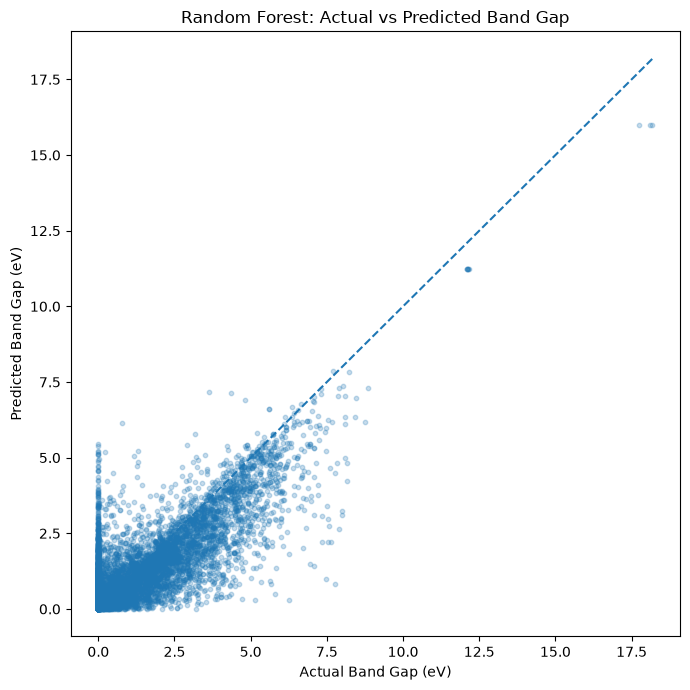

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.25,
    s=10
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Band Gap (eV)")
plt.ylabel("Predicted Band Gap (eV)")
plt.title("Random Forest: Actual vs Predicted Band Gap")

plt.tight_layout()
plt.show()

In [63]:
results = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_rf
})

results["absolute_error"] = (
    results["actual"] - results["predicted"]
).abs()

print("Overall MAE:")
print(results["absolute_error"].mean())

print("\nMAE for zero-band-gap materials:")
zero_mask = results["actual"] == 0
print(results.loc[zero_mask, "absolute_error"].mean())

print("\nMAE for non-zero-band-gap materials:")
nonzero_mask = results["actual"] > 0
print(results.loc[nonzero_mask, "absolute_error"].mean())

Overall MAE:
0.32576401330886245

MAE for zero-band-gap materials:
0.1580162651153927

MAE for non-zero-band-gap materials:
0.7408970160537007


In [64]:
# Get the fitted preprocessing step
fitted_preprocessor = random_forest_model.named_steps["preprocessor"]

# Get the fitted Random Forest
fitted_rf = random_forest_model.named_steps["model"]

# Get feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

# Get feature importances
importances = fitted_rf.feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort from most to least important
importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df.head(25).to_string(index=False))

                feature  importance
 num__min_atomic_radius    0.191692
num__mean_atomic_radius    0.106112
 num__max_atomic_number    0.103231
   num__max_atomic_mass    0.096646
num__mean_atomic_number    0.095923
       num__total_atoms    0.077089
  num__mean_atomic_mass    0.076495
 num__max_atomic_radius    0.068774
   num__min_atomic_mass    0.018477
 num__min_atomic_number    0.018303
      num__num_elements    0.018104
     cat__spg_number_62    0.009040
        cat__crys_cubic    0.007191
      cat__spg_number_1    0.006361
 cat__crys_orthorhombic    0.006124
   cat__crys_tetragonal    0.005978
   cat__crys_monoclinic    0.005904
    cat__spg_number_221    0.005799
     cat__spg_number_14    0.005583
     cat__crys_trigonal    0.005268
    cat__spg_number_225    0.005037
     cat__spg_number_99    0.003673
     cat__spg_number_15    0.003099
    cat__crys_hexagonal    0.002725
     cat__spg_number_12    0.002256


In [65]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    random_forest_model,
    X,
    y,
    cv=cv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1
)

mae_scores = -cv_results["test_mae"]
rmse_scores = -cv_results["test_rmse"]
r2_scores = cv_results["test_r2"]

print("5-Fold Cross-Validation")
print("-----------------------")

print(f"MAE  : {mae_scores.mean():.4f} ± {mae_scores.std():.4f} eV")
print(f"RMSE : {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f} eV")
print(f"R²   : {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

print("\nIndividual fold results:")
for i in range(5):
    print(
        f"Fold {i+1}: "
        f"MAE={mae_scores[i]:.4f}, "
        f"RMSE={rmse_scores[i]:.4f}, "
        f"R²={r2_scores[i]:.4f}"
    )

5-Fold Cross-Validation
-----------------------
MAE  : 0.3211 ± 0.0027 eV
RMSE : 0.6846 ± 0.0056 eV
R²   : 0.7271 ± 0.0035

Individual fold results:
Fold 1: MAE=0.3255, RMSE=0.6937, R²=0.7316
Fold 2: MAE=0.3227, RMSE=0.6866, R²=0.7241
Fold 3: MAE=0.3186, RMSE=0.6770, R²=0.7271
Fold 4: MAE=0.3198, RMSE=0.6843, R²=0.7224
Fold 5: MAE=0.3187, RMSE=0.6812, R²=0.7301


In [66]:
results["gap_region"] = pd.cut(
    results["actual"],
    bins=[-0.001, 0.001, 1, 2, 3, 5, 10, np.inf],
    labels=[
        "0 eV",
        "0–1 eV",
        "1–2 eV",
        "2–3 eV",
        "3–5 eV",
        "5–10 eV",
        ">10 eV"
    ]
)

region_mae = (
    results
    .groupby("gap_region", observed=False)["absolute_error"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "MAE"})
)

print(region_mae)

            count       MAE
gap_region                 
0 eV        13383  0.158227
0–1 eV       1963  0.412142
1–2 eV       1156  0.568567
2–3 eV        852  0.823922
3–5 eV       1028  1.154789
5–10 eV       390  1.625189
>10 eV          9  1.266283


In [67]:
# Create binary target
y_class = (y > 0).astype(int)

print("Classification target:")
print("----------------------")

print("Total materials:", len(y_class))
print("Zero-gap materials:", (y_class == 0).sum())
print("Non-zero-gap materials:", (y_class == 1).sum())

print("\nPercentages:")
print(
    "Zero-gap:",
    (y_class == 0).mean() * 100
)

print(
    "Non-zero-gap:",
    (y_class == 1).mean() * 100
)

Classification target:
----------------------
Total materials: 93902
Zero-gap materials: 67062
Non-zero-gap materials: 26840

Percentages:
Zero-gap: 71.41700922238078
Non-zero-gap: 28.582990777619223


In [68]:
from sklearn.model_selection import train_test_split

X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Training samples:", len(X_class_train))
print("Testing samples:", len(X_class_test))

print("\nTraining class distribution:")
print(y_class_train.value_counts())
print(y_class_train.value_counts(normalize=True) * 100)

print("\nTesting class distribution:")
print(y_class_test.value_counts())
print(y_class_test.value_counts(normalize=True) * 100)

Training samples: 75121
Testing samples: 18781

Training class distribution:
target_bandgap
0    53649
1    21472
Name: count, dtype: int64
target_bandgap
0    71.416781
1    28.583219
Name: proportion, dtype: float64

Testing class distribution:
target_bandgap
0    13413
1     5368
Name: count, dtype: int64
target_bandgap
0    71.417922
1    28.582078
Name: proportion, dtype: float64


In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_classifier = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]
)

print("Training classifier...")

rf_classifier.fit(
    X_class_train,
    y_class_train
)

print("Training complete!")

Training classifier...
Training complete!


In [70]:
class_weight="balanced"

In [71]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_class_pred = rf_classifier.predict(X_class_test)

y_class_prob = rf_classifier.predict_proba(
    X_class_test
)[:, 1]

accuracy = accuracy_score(
    y_class_test,
    y_class_pred
)

precision = precision_score(
    y_class_test,
    y_class_pred
)

recall = recall_score(
    y_class_test,
    y_class_pred
)

f1 = f1_score(
    y_class_test,
    y_class_pred
)

roc_auc = roc_auc_score(
    y_class_test,
    y_class_prob
)

print("Random Forest Classification Results")
print("------------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_class_test,
    y_class_pred
))

print("\nClassification Report:")
print(classification_report(
    y_class_test,
    y_class_pred,
    target_names=[
        "Zero band gap",
        "Non-zero band gap"
    ]
))

Random Forest Classification Results
------------------------------------
Accuracy : 0.8680
Precision: 0.7171
Recall   : 0.8886
F1-score : 0.7937
ROC-AUC  : 0.9435

Confusion Matrix:
[[11531  1882]
 [  598  4770]]

Classification Report:
                   precision    recall  f1-score   support

    Zero band gap       0.95      0.86      0.90     13413
Non-zero band gap       0.72      0.89      0.79      5368

         accuracy                           0.87     18781
        macro avg       0.83      0.87      0.85     18781
     weighted avg       0.88      0.87      0.87     18781



In [72]:
# Select only materials with non-zero band gaps
nonzero_mask = y > 0

X_nonzero = X.loc[nonzero_mask].copy()
y_nonzero = y.loc[nonzero_mask].copy()

print("Non-zero band-gap dataset")
print("-------------------------")
print("Samples:", len(X_nonzero))
print("Features:", X_nonzero.shape[1])

print("\nTarget statistics:")
print(y_nonzero.describe())

Non-zero band-gap dataset
-------------------------
Samples: 26840
Features: 13

Target statistics:
count    26840.000000
mean         2.023670
std          1.756369
min          0.001000
25%          0.593000
50%          1.584000
75%          3.061250
max         18.179000
Name: target_bandgap, dtype: float64


In [73]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Create bins for approximate stratification
gap_bins = pd.cut(
    y_nonzero,
    bins=[0, 1, 2, 3, 5, 10, np.inf],
    labels=False,
    include_lowest=True
)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_nonzero,
    y_nonzero,
    test_size=0.20,
    random_state=42,
    stratify=gap_bins
)

print("Training samples:", len(X_reg_train))
print("Testing samples:", len(X_reg_test))

print("\nTraining target statistics:")
print(y_reg_train.describe())

print("\nTesting target statistics:")
print(y_reg_test.describe())

Training samples: 21472
Testing samples: 5368

Training target statistics:
count    21472.000000
mean         2.023266
std          1.754896
min          0.001000
25%          0.592000
50%          1.588000
75%          3.066000
max         18.179000
Name: target_bandgap, dtype: float64

Testing target statistics:
count    5368.000000
mean        2.025286
std         1.762413
min         0.001000
25%         0.599500
50%         1.564000
75%         3.051000
max        17.733000
Name: target_bandgap, dtype: float64


In [74]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_nonzero_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Training Stage-2 Random Forest...")

rf_nonzero_model.fit(
    X_reg_train,
    y_reg_train
)

print("Training complete!")

# Predictions
y_reg_pred = rf_nonzero_model.predict(X_reg_test)

# Metrics
nonzero_mae = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)

nonzero_rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred
    )
)

nonzero_r2 = r2_score(
    y_reg_test,
    y_reg_pred
)

print("\nStage-2 Random Forest Results")
print("-----------------------------")
print(f"MAE  : {nonzero_mae:.4f} eV")
print(f"RMSE : {nonzero_rmse:.4f} eV")
print(f"R²   : {nonzero_r2:.4f}")

Training Stage-2 Random Forest...
Training complete!

Stage-2 Random Forest Results
-----------------------------
MAE  : 0.6390 eV
RMSE : 0.9496 eV
R²   : 0.7097


In [75]:
import pandas as pd
import numpy as np

stage2_results = pd.DataFrame({
    "actual": y_reg_test.values,
    "predicted": y_reg_pred
})

stage2_results["error"] = (
    stage2_results["predicted"] -
    stage2_results["actual"]
)

stage2_results["absolute_error"] = (
    stage2_results["error"].abs()
)

stage2_results.head()

,actual,predicted,error,absolute_error
0,1.717,2.207204,0.490204,0.490204
1,3.634,3.754196,0.120196,0.120196
2,4.987,3.813980,-1.173020,1.173020
3,1.058,1.531396,0.473396,0.473396
4,0.766,0.555959,-0.210041,0.210041


In [81]:
from sklearn.model_selection import train_test_split

# Create binary target
y_class = (y > 0).astype(int)

# ONE master split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining target:")
print("Zero-gap:", (y_train == 0).sum())
print("Non-zero:", (y_train > 0).sum())

print("\nTest target:")
print("Zero-gap:", (y_test == 0).sum())
print("Non-zero:", (y_test > 0).sum())

Training samples: 75121
Test samples: 18781

Training target:
Zero-gap: 53649
Non-zero: 21472

Test target:
Zero-gap: 13413
Non-zero: 5368


In [82]:
y_class_train = (y_train > 0).astype(int)
y_class_test = (y_test > 0).astype(int)

print(y_class_train.value_counts())
print(y_class_test.value_counts())

target_bandgap
0    53649
1    21472
Name: count, dtype: int64
target_bandgap
0    13413
1     5368
Name: count, dtype: int64


In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_classifier_clean = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]
)

print("Training Stage-1 classifier...")

rf_classifier_clean.fit(
    X_train,
    y_class_train
)

print("Stage-1 training complete!")

Training Stage-1 classifier...
Stage-1 training complete!


In [84]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

y_class_pred = rf_classifier_clean.predict(X_test)
y_class_prob = rf_classifier_clean.predict_proba(X_test)[:, 1]

print("Stage-1 Results")
print("----------------")

print(
    "Accuracy :",
    accuracy_score(y_class_test, y_class_pred)
)

print(
    "Precision:",
    precision_score(y_class_test, y_class_pred)
)

print(
    "Recall   :",
    recall_score(y_class_test, y_class_pred)
)

print(
    "F1       :",
    f1_score(y_class_test, y_class_pred)
)

print(
    "ROC-AUC  :",
    roc_auc_score(y_class_test, y_class_prob)
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_class_test, y_class_pred))

Stage-1 Results
----------------
Accuracy : 0.8679516532665992
Precision: 0.717077570655442
Recall   : 0.8885991058122206
F1       : 0.7936772046589018
ROC-AUC  : 0.943525605150063

Confusion Matrix:
[[11531  1882]
 [  598  4770]]


In [85]:
nonzero_train_mask = y_train > 0

X_reg_train = X_train.loc[nonzero_train_mask].copy()
y_reg_train = y_train.loc[nonzero_train_mask].copy()

print("Stage-2 training samples:", len(X_reg_train))
print("Stage-2 target mean:", y_reg_train.mean())
print("Stage-2 target median:", y_reg_train.median())
print("Stage-2 target max:", y_reg_train.max())

Stage-2 training samples: 21472
Stage-2 target mean: 2.023831175484352
Stage-2 target median: 1.581
Stage-2 target max: 18.179


In [86]:
from sklearn.ensemble import RandomForestRegressor

rf_nonzero_clean = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Training Stage-2 regressor...")

rf_nonzero_clean.fit(
    X_reg_train,
    y_reg_train
)

print("Stage-2 training complete!")

Training Stage-2 regressor...
Stage-2 training complete!


In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    "num_elements",
    "total_atoms",
    "mean_atomic_number",
    "min_atomic_number",
    "max_atomic_number",
    "mean_atomic_mass",
    "min_atomic_mass",
    "max_atomic_mass",
    "mean_atomic_radius",
    "min_atomic_radius",
    "max_atomic_radius"
]

categorical_features = [
    "crys",
    "spg_number"
]


def create_preprocessor():

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

In [89]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier_clean = Pipeline(
    steps=[
        ("preprocessor", create_preprocessor()),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]
)

print("Training Stage-1 classifier...")

rf_classifier_clean.fit(
    X_train,
    y_class_train
)

print("Stage-1 training complete!")

Training Stage-1 classifier...
Stage-1 training complete!


In [90]:
stage1_pred = rf_classifier_clean.predict(X_test)

print("Predicted zero-gap:",
      (stage1_pred == 0).sum())

print("Predicted non-zero:",
      (stage1_pred == 1).sum())

Predicted zero-gap: 12129
Predicted non-zero: 6652


In [91]:
from sklearn.ensemble import RandomForestRegressor

rf_nonzero_clean = Pipeline(
    steps=[
        ("preprocessor", create_preprocessor()),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Training Stage-2 regressor...")

rf_nonzero_clean.fit(
    X_reg_train,
    y_reg_train
)

print("Stage-2 training complete!")

Training Stage-2 regressor...
Stage-2 training complete!


In [92]:
import numpy as np

final_pred = np.zeros(len(X_test))

predicted_nonzero_mask = stage1_pred == 1

final_pred[predicted_nonzero_mask] = (
    rf_nonzero_clean.predict(
        X_test.loc[predicted_nonzero_mask]
    )
)

print("Final predictions generated.")
print("Zero predictions:",
      (final_pred == 0).sum())

print("Non-zero predictions:",
      (final_pred > 0).sum())

Final predictions generated.
Zero predictions: 12129
Non-zero predictions: 6652


In [93]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

final_mae = mean_absolute_error(
    y_test,
    final_pred
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_pred
    )
)

final_r2 = r2_score(
    y_test,
    final_pred
)

print("\nEnd-to-End Two-Stage Results")
print("-----------------------------")
print(f"MAE  : {final_mae:.4f} eV")
print(f"RMSE : {final_rmse:.4f} eV")
print(f"R²   : {final_r2:.4f}")


End-to-End Two-Stage Results
-----------------------------
MAE  : 0.3447 eV
RMSE : 0.7982 eV
R²   : 0.6279


In [94]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Actual classes
actual_nonzero = y_test > 0

# Predicted classes
predicted_nonzero = stage1_pred == 1

# --------------------------------------------------
# 1. Overall
# --------------------------------------------------

print("Overall")
print("-------")
print(f"MAE  : {mean_absolute_error(y_test, final_pred):.4f} eV")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, final_pred)):.4f} eV")


# --------------------------------------------------
# 2. Actual zero-gap materials
# --------------------------------------------------

zero_mask = y_test == 0

zero_mae = mean_absolute_error(
    y_test[zero_mask],
    final_pred[zero_mask]
)

zero_rmse = np.sqrt(
    mean_squared_error(
        y_test[zero_mask],
        final_pred[zero_mask]
    )
)

print("\nActual zero-gap materials")
print("-------------------------")
print("Count:", zero_mask.sum())
print(f"MAE  : {zero_mae:.4f} eV")
print(f"RMSE : {zero_rmse:.4f} eV")


# --------------------------------------------------
# 3. Actual non-zero-gap materials
# --------------------------------------------------

nonzero_mask = y_test > 0

nonzero_mae = mean_absolute_error(
    y_test[nonzero_mask],
    final_pred[nonzero_mask]
)

nonzero_rmse = np.sqrt(
    mean_squared_error(
        y_test[nonzero_mask],
        final_pred[nonzero_mask]
    )
)

print("\nActual non-zero-gap materials")
print("-----------------------------")
print("Count:", nonzero_mask.sum())
print(f"MAE  : {nonzero_mae:.4f} eV")
print(f"RMSE : {nonzero_rmse:.4f} eV")


# --------------------------------------------------
# 4. Confusion matrix
# --------------------------------------------------

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    actual_nonzero,
    predicted_nonzero
)

print("\nConfusion Matrix")
print("----------------")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)


# --------------------------------------------------
# 5. False-positive error
# --------------------------------------------------

false_positive_mask = (
    (y_test == 0) &
    (stage1_pred == 1)
)

fp_errors = final_pred[false_positive_mask]

print("\nFalse positives")
print("---------------")
print("Count:", false_positive_mask.sum())

if len(fp_errors) > 0:
    print(f"Mean predicted gap : {fp_errors.mean():.4f} eV")
    print(f"Maximum predicted gap : {fp_errors.max():.4f} eV")
    print(f"MAE contribution : {np.mean(np.abs(fp_errors)):.4f} eV")


# --------------------------------------------------
# 6. False-negative error
# --------------------------------------------------

false_negative_mask = (
    (y_test > 0) &
    (stage1_pred == 0)
)

fn_errors = y_test[false_negative_mask]

print("\nFalse negatives")
print("---------------")
print("Count:", false_negative_mask.sum())

if len(fn_errors) > 0:
    print(f"Mean actual gap : {fn_errors.mean():.4f} eV")
    print(f"Maximum actual gap : {fn_errors.max():.4f} eV")

Overall
-------
MAE  : 0.3447 eV
RMSE : 0.7982 eV

Actual zero-gap materials
-------------------------
Count: 13413
MAE  : 0.2130 eV
RMSE : 0.6895 eV

Actual non-zero-gap materials
-----------------------------
Count: 5368
MAE  : 0.6735 eV
RMSE : 1.0203 eV

Confusion Matrix
----------------
[[11531  1882]
 [  598  4770]]

TN: 11531
FP: 1882
FN: 598
TP: 4770

False positives
---------------
Count: 1882
Mean predicted gap : 1.5184 eV
Maximum predicted gap : 8.3916 eV
MAE contribution : 1.5184 eV

False negatives
---------------
Count: 598
Mean actual gap : 0.8708 eV
Maximum actual gap : 8.5530 eV


In [95]:
stage1_pred = rf_classifier_clean.predict(X_test)

In [96]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Get probability of non-zero class
stage1_probability = rf_classifier_clean.predict_proba(X_test)[:, 1]

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

results = []

for threshold in thresholds:

    # Stage 1 decision
    predicted_nonzero = stage1_probability >= threshold

    # Start with all predictions = 0
    threshold_pred = np.zeros(len(X_test))

    # Send predicted non-zero materials to Stage 2
    threshold_pred[predicted_nonzero] = (
        rf_nonzero_clean.predict(
            X_test.loc[predicted_nonzero]
        )
    )

    # Metrics
    mae = mean_absolute_error(
        y_test,
        threshold_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            threshold_pred
        )
    )

    r2 = r2_score(
        y_test,
        threshold_pred
    )

    # Classification counts
    actual_nonzero = y_test > 0

    tp = np.sum(
        predicted_nonzero & actual_nonzero
    )

    fp = np.sum(
        predicted_nonzero & ~actual_nonzero
    )

    fn = np.sum(
        ~predicted_nonzero & actual_nonzero
    )

    tn = np.sum(
        ~predicted_nonzero & ~actual_nonzero
    )

    results.append({
        "threshold": threshold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

threshold_results = pd.DataFrame(results)

print(threshold_results)

   threshold       MAE      RMSE        R2    TP    FP    FN     TN
0        0.3  0.443258  0.885678  0.541879  5174  3616   194   9797
1        0.4  0.389071  0.839343  0.588559  5012  2660   356  10753
2        0.5  0.344652  0.798170  0.627935  4770  1882   598  11531
3        0.6  0.312239  0.773431  0.650641  4348  1230  1020  12183
4        0.7  0.303708  0.793666  0.632122  3737   755  1631  12658
5        0.8  0.321433  0.880644  0.547072  2804   330  2564  13083
6        0.9  0.417367  1.114348  0.274779  1350    69  4018  13344


In [98]:
# Choose the threshold we want to investigate
threshold = 0.7

stage1_probability = rf_classifier_clean.predict_proba(X_test)[:, 1]
predicted_nonzero = stage1_probability >= threshold

threshold_pred = np.zeros(len(X_test))

threshold_pred[predicted_nonzero] = (
    rf_nonzero_clean.predict(
        X_test.loc[predicted_nonzero]
    )
)

# Error dataframe
error_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": threshold_pred
})

error_df["absolute_error"] = (
    error_df["actual"] - error_df["predicted"]
).abs()

# Gap regions
bins = [-0.001, 0, 1, 2, 3, 5, 10, np.inf]
labels = [
    "0 eV",
    "0–1 eV",
    "1–2 eV",
    "2–3 eV",
    "3–5 eV",
    "5–10 eV",
    ">10 eV"
]

error_df["gap_region"] = pd.cut(
    error_df["actual"],
    bins=bins,
    labels=labels
)

range_results = (
    error_df
    .groupby("gap_region", observed=False)
    .agg(
        count=("actual", "size"),
        MAE=("absolute_error", "mean")
    )
)

print(range_results)

            count       MAE
gap_region                 
0 eV        13413  0.098766
0–1 eV       1996  0.553693
1–2 eV       1107  0.762891
2–3 eV        850  0.866477
3–5 eV       1031  1.111855
5–10 eV       383  1.425106
>10 eV          1  0.854768


In [101]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

def create_preprocessor():

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

In [102]:
rf_single_clean = Pipeline(
    steps=[
        ("preprocessor", create_preprocessor()),

        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Training clean single-stage Random Forest...")

rf_single_clean.fit(
    X_train,
    y_train
)

print("Training complete!")

Training clean single-stage Random Forest...
Training complete!


In [103]:
rf_predictions = rf_single_clean.predict(X_test)

print("Predictions generated!")
print("Number of predictions:", len(rf_predictions))

Predictions generated!
Number of predictions: 18781


In [104]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Clean Single-Stage Random Forest")
print("--------------------------------")
print(f"MAE  : {rf_mae:.4f} eV")
print(f"RMSE : {rf_rmse:.4f} eV")
print(f"R²   : {rf_r2:.4f}")

Clean Single-Stage Random Forest
--------------------------------
MAE  : 0.3267 eV
RMSE : 0.7028 eV
R²   : 0.7115


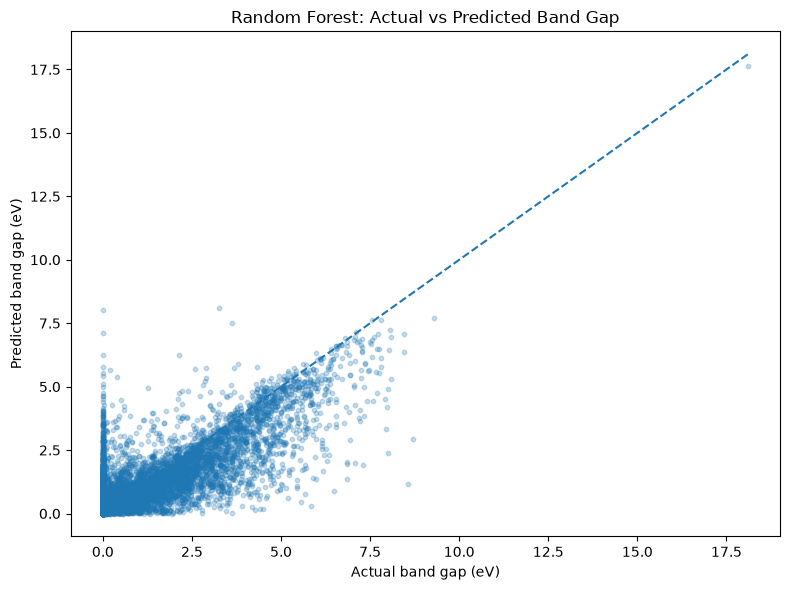

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.25,
    s=10
)

max_value = max(
    y_test.max(),
    rf_predictions.max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual band gap (eV)")
plt.ylabel("Predicted band gap (eV)")
plt.title("Random Forest: Actual vs Predicted Band Gap")

plt.tight_layout()
plt.show()

In [106]:
# ---------------------------------------
# Numerical prediction diagnostics
# ---------------------------------------

residuals = y_test.values - rf_predictions
absolute_errors = np.abs(residuals)

print("Prediction diagnostics")
print("----------------------")

print(f"Actual minimum       : {y_test.min():.4f} eV")
print(f"Actual maximum       : {y_test.max():.4f} eV")

print(f"Predicted minimum    : {rf_predictions.min():.4f} eV")
print(f"Predicted maximum    : {rf_predictions.max():.4f} eV")

print(f"Mean residual        : {residuals.mean():.4f} eV")
print(f"Median residual      : {np.median(residuals):.4f} eV")

print(f"Mean absolute error  : {absolute_errors.mean():.4f} eV")
print(f"Median absolute error: {np.median(absolute_errors):.4f} eV")

print("\nLarge-error statistics")
print("----------------------")

print(
    "Errors > 1 eV :",
    np.sum(absolute_errors > 1)
)

print(
    "Errors > 2 eV :",
    np.sum(absolute_errors > 2)
)

print(
    "Errors > 3 eV :",
    np.sum(absolute_errors > 3)
)

print(
    "Errors > 5 eV :",
    np.sum(absolute_errors > 5)
)

Prediction diagnostics
----------------------
Actual minimum       : 0.0000 eV
Actual maximum       : 18.0980 eV
Predicted minimum    : 0.0000 eV
Predicted maximum    : 17.6277 eV
Mean residual        : -0.0021 eV
Median residual      : -0.0012 eV
Mean absolute error  : 0.3267 eV
Median absolute error: 0.0432 eV

Large-error statistics
----------------------
Errors > 1 eV : 1935
Errors > 2 eV : 590
Errors > 3 eV : 187
Errors > 5 eV : 18


In [107]:
error_df_single = pd.DataFrame({
    "actual": y_test.values,
    "predicted": rf_predictions
})

error_df_single["absolute_error"] = (
    error_df_single["actual"] -
    error_df_single["predicted"]
).abs()

bins = [-0.001, 0, 1, 2, 3, 5, 10, np.inf]

labels = [
    "0 eV",
    "0–1 eV",
    "1–2 eV",
    "2–3 eV",
    "3–5 eV",
    "5–10 eV",
    ">10 eV"
]

error_df_single["gap_region"] = pd.cut(
    error_df_single["actual"],
    bins=bins,
    labels=labels
)

single_region_results = (
    error_df_single
    .groupby("gap_region", observed=False)
    .agg(
        count=("actual", "size"),
        MAE=("absolute_error", "mean")
    )
)

print(single_region_results)

            count       MAE
gap_region                 
0 eV        13413  0.162832
0–1 eV       1996  0.420284
1–2 eV       1107  0.570436
2–3 eV        850  0.822958
3–5 eV       1031  1.163264
5–10 eV       383  1.520025
>10 eV          1  0.470284


In [108]:
from jarvis.core.specie import Specie

test_element = Specie("Si")

properties_to_test = [
    "X",              # electronegativity
    "first_ion_en",   # first ionization energy
    "elec_aff",       # electron affinity
    "nsvalence",      # s valence electrons
    "npvalence",      # p valence electrons
    "ndvalence",      # d valence electrons
    "nfvalence",      # f valence electrons
    "row",
    "coulmn",
    "is_transition_metal",
    "is_metalloid",
    "is_halogen",
    "is_alkali",
    "is_alkaline",
]

for prop in properties_to_test:
    value = test_element.element_property(prop)
    print(f"{prop:25s}: {value}")

X                        : 1.9
first_ion_en             : 8.15168
elec_aff                 : 1.336
nsvalence                : 2
npvalence                : 2
ndvalence                : 0
nfvalence                : 0
row                      : 3
coulmn                   : 14
is_transition_metal      : 0
is_metalloid             : 1
is_halogen               : 0
is_alkali                : 0
is_alkaline              : 0


In [109]:
def advanced_composition_descriptors(formula):
    composition = parse_formula(formula)

    elements = list(composition.keys())
    amounts = np.array(list(composition.values()), dtype=float)

    total_atoms = amounts.sum()
    fractions = amounts / total_atoms

    # Store elemental properties
    electronegativities = []
    ionization_energies = []
    electron_affinities = []

    s_valence = []
    p_valence = []
    d_valence = []
    f_valence = []

    rows = []
    columns = []

    for element in elements:
        specie = Specie(element)

        electronegativities.append(
            specie.element_property("X")
        )

        ionization_energies.append(
            specie.element_property("first_ion_en")
        )

        electron_affinities.append(
            specie.element_property("elec_aff")
        )

        s_valence.append(
            specie.element_property("nsvalence")
        )

        p_valence.append(
            specie.element_property("npvalence")
        )

        d_valence.append(
            specie.element_property("ndvalence")
        )

        f_valence.append(
            specie.element_property("nfvalence")
        )

        rows.append(
            specie.element_property("row")
        )

        columns.append(
            specie.element_property("coulmn")
        )

    # Convert to numpy
    electronegativities = np.array(electronegativities, dtype=float)
    ionization_energies = np.array(ionization_energies, dtype=float)
    electron_affinities = np.array(electron_affinities, dtype=float)

    s_valence = np.array(s_valence, dtype=float)
    p_valence = np.array(p_valence, dtype=float)
    d_valence = np.array(d_valence, dtype=float)
    f_valence = np.array(f_valence, dtype=float)

    rows = np.array(rows, dtype=float)
    columns = np.array(columns, dtype=float)

    # Weighted averages
    mean_electronegativity = np.sum(
        electronegativities * fractions
    )

    mean_ionization_energy = np.sum(
        ionization_energies * fractions
    )

    mean_electron_affinity = np.sum(
        electron_affinities * fractions
    )

    mean_s_valence = np.sum(
        s_valence * fractions
    )

    mean_p_valence = np.sum(
        p_valence * fractions
    )

    mean_d_valence = np.sum(
        d_valence * fractions
    )

    mean_f_valence = np.sum(
        f_valence * fractions
    )

    mean_row = np.sum(rows * fractions)
    mean_column = np.sum(columns * fractions)

    # Chemical contrast
    electronegativity_difference = (
        electronegativities.max()
        - electronegativities.min()
    )

    return {
        "mean_electronegativity": mean_electronegativity,
        "min_electronegativity": electronegativities.min(),
        "max_electronegativity": electronegativities.max(),
        "electronegativity_difference": electronegativity_difference,

        "mean_ionization_energy": mean_ionization_energy,

        "mean_electron_affinity": mean_electron_affinity,

        "mean_s_valence": mean_s_valence,
        "mean_p_valence": mean_p_valence,
        "mean_d_valence": mean_d_valence,
        "mean_f_valence": mean_f_valence,

        "mean_period": mean_row,
        "mean_group": mean_column,
    }

In [110]:
advanced_composition_descriptors("SiO2")

{'mean_electronegativity': np.float64(2.9266666666666663),
 'min_electronegativity': np.float64(1.9),
 'max_electronegativity': np.float64(3.44),
 'electronegativity_difference': np.float64(1.54),
 'mean_ionization_energy': np.float64(11.795926666666666),
 'mean_electron_affinity': np.float64(1.3853333333333333),
 'mean_s_valence': np.float64(2.0),
 'mean_p_valence': np.float64(3.333333333333333),
 'mean_d_valence': np.float64(0.0),
 'mean_f_valence': np.float64(0.0),
 'mean_period': np.float64(2.333333333333333),
 'mean_group': np.float64(15.333333333333332)}

In [111]:
advanced_descriptors = []

for i, formula in enumerate(df["formula"]):

    try:
        descriptors = advanced_composition_descriptors(formula)
        advanced_descriptors.append(descriptors)

    except Exception as e:
        print(f"Error at row {i}: {formula}")
        print(e)
        advanced_descriptors.append({})

In [112]:
advanced_df = pd.DataFrame(advanced_descriptors)

print("Shape:", advanced_df.shape)
print(advanced_df.head())

Shape: (93902, 12)
   mean_electronegativity  min_electronegativity  max_electronegativity  \
0                1.880000                   1.54                   2.18   
1                1.922857                   1.22                   2.04   
2                1.885000                   1.57                   2.20   
3                1.420000                   0.82                   2.02   
4                2.243333                   1.63                   2.55   

   electronegativity_difference  mean_ionization_energy  \
0                          0.64                8.123695   
1                          0.82                7.961003   
2                          0.63                8.611033   
3                          1.20                5.813082   
4                          0.92                8.750323   

   mean_electron_affinity  mean_s_valence  mean_p_valence  mean_d_valence  \
0                0.844000            1.75        1.250000        5.500000   
1                0.30

In [113]:
print(advanced_df.isna().sum())

mean_electronegativity          0
min_electronegativity           0
max_electronegativity           0
electronegativity_difference    0
mean_ionization_energy          0
mean_electron_affinity          0
mean_s_valence                  0
mean_p_valence                  0
mean_d_valence                  0
mean_f_valence                  0
mean_period                     0
mean_group                      0
dtype: int64


In [114]:
print(
    advanced_df.describe().T[
        ["mean", "std", "min", "max"]
    ]
)

                                    mean         std     min        max
mean_electronegativity          2.089952    0.548860     0.0   3.980000
min_electronegativity           1.283024    0.467582     0.0   3.980000
max_electronegativity           2.655384    0.723704     0.0   3.980000
electronegativity_difference    1.372360    0.825398     0.0   3.980000
mean_ionization_energy        -94.769029  732.564890 -9999.0  24.587387
mean_electron_affinity       -102.791675  731.928816 -9999.0   3.490000
mean_s_valence               -101.974779  731.984144 -9999.0   2.000000
mean_p_valence               -102.209531  731.992914 -9999.0   6.000000
mean_d_valence               -100.349926  732.008677 -9999.0  10.000000
mean_f_valence               -102.050136  731.889182 -9999.0  14.000000
mean_period                   -99.828349  732.097301 -9999.0   9.000000
mean_group                    -93.459795  732.600056 -9999.0  18.000000


In [115]:
print(advanced_df.isna().sum())

mean_electronegativity          0
min_electronegativity           0
max_electronegativity           0
electronegativity_difference    0
mean_ionization_energy          0
mean_electron_affinity          0
mean_s_valence                  0
mean_p_valence                  0
mean_d_valence                  0
mean_f_valence                  0
mean_period                     0
mean_group                      0
dtype: int64


In [116]:
print(advanced_df.describe().T)

                                count        mean         std     min  \
mean_electronegativity        93902.0    2.089952    0.548860     0.0   
min_electronegativity         93902.0    1.283024    0.467582     0.0   
max_electronegativity         93902.0    2.655384    0.723704     0.0   
electronegativity_difference  93902.0    1.372360    0.825398     0.0   
mean_ionization_energy        93902.0  -94.769029  732.564890 -9999.0   
mean_electron_affinity        93902.0 -102.791675  731.928816 -9999.0   
mean_s_valence                93902.0 -101.974779  731.984144 -9999.0   
mean_p_valence                93902.0 -102.209531  731.992914 -9999.0   
mean_d_valence                93902.0 -100.349926  732.008677 -9999.0   
mean_f_valence                93902.0 -102.050136  731.889182 -9999.0   
mean_period                   93902.0  -99.828349  732.097301 -9999.0   
mean_group                    93902.0  -93.459795  732.600056 -9999.0   

                                   25%        50% 

In [117]:
sentinel_counts = {}

for column in advanced_df.columns:
    sentinel_counts[column] = (advanced_df[column] == -9999).sum()

sentinel_counts = pd.Series(sentinel_counts)

print(sentinel_counts)

mean_electronegativity           0
min_electronegativity            0
max_electronegativity            0
electronegativity_difference     0
mean_ionization_energy          57
mean_electron_affinity          57
mean_s_valence                  57
mean_p_valence                  57
mean_d_valence                  57
mean_f_valence                  57
mean_period                     57
mean_group                      57
dtype: int64


In [118]:
print(
    "Rows containing at least one -9999:",
    (advanced_df == -9999).any(axis=1).sum()
)

Rows containing at least one -9999: 57


In [119]:
advanced_df_clean = advanced_df.replace(-9999, np.nan)

In [120]:
print(advanced_df_clean.isna().sum())

mean_electronegativity           0
min_electronegativity            0
max_electronegativity            0
electronegativity_difference     0
mean_ionization_energy          57
mean_electron_affinity          57
mean_s_valence                  57
mean_p_valence                  57
mean_d_valence                  57
mean_f_valence                  57
mean_period                     57
mean_group                      57
dtype: int64


In [122]:
enhanced_features_df = pd.concat(
    [
        features_df.drop(columns=["target_bandgap"]),
        advanced_df_clean
    ],
    axis=1
)

enhanced_features_df["target_bandgap"] = features_df["target_bandgap"]

print(enhanced_features_df.shape)
print(enhanced_features_df.columns.tolist())

(93902, 26)
['num_elements', 'total_atoms', 'mean_atomic_number', 'min_atomic_number', 'max_atomic_number', 'mean_atomic_mass', 'min_atomic_mass', 'max_atomic_mass', 'mean_atomic_radius', 'min_atomic_radius', 'max_atomic_radius', 'crys', 'spg_number', 'mean_electronegativity', 'min_electronegativity', 'max_electronegativity', 'electronegativity_difference', 'mean_ionization_energy', 'mean_electron_affinity', 'mean_s_valence', 'mean_p_valence', 'mean_d_valence', 'mean_f_valence', 'mean_period', 'mean_group', 'target_bandgap']


In [123]:
print(
    enhanced_features_df[
        enhanced_features_df.columns
    ].isna().sum()
)

num_elements                     0
total_atoms                      0
mean_atomic_number               0
min_atomic_number                0
max_atomic_number                0
mean_atomic_mass                 0
min_atomic_mass                  0
max_atomic_mass                  0
mean_atomic_radius              27
min_atomic_radius               27
max_atomic_radius               27
crys                             0
spg_number                       0
mean_electronegativity           0
min_electronegativity            0
max_electronegativity            0
electronegativity_difference     0
mean_ionization_energy          57
mean_electron_affinity          57
mean_s_valence                  57
mean_p_valence                  57
mean_d_valence                  57
mean_f_valence                  57
mean_period                     57
mean_group                      57
target_bandgap                   0
dtype: int64


In [124]:
print(sentinel_counts)

mean_electronegativity           0
min_electronegativity            0
max_electronegativity            0
electronegativity_difference     0
mean_ionization_energy          57
mean_electron_affinity          57
mean_s_valence                  57
mean_p_valence                  57
mean_d_valence                  57
mean_f_valence                  57
mean_period                     57
mean_group                      57
dtype: int64


In [125]:
print(
    "Rows containing at least one -9999:",
    (advanced_df == -9999).any(axis=1).sum()
)

Rows containing at least one -9999: 57


In [127]:
enhanced_features_df = pd.concat(
    [
        features_df.drop(columns=["target_bandgap"]),
        advanced_df_clean
    ],
    axis=1
)

enhanced_features_df["target_bandgap"] = features_df["target_bandgap"]

print("Shape:", enhanced_features_df.shape)
print(enhanced_features_df.columns.tolist())

Shape: (93902, 26)
['num_elements', 'total_atoms', 'mean_atomic_number', 'min_atomic_number', 'max_atomic_number', 'mean_atomic_mass', 'min_atomic_mass', 'max_atomic_mass', 'mean_atomic_radius', 'min_atomic_radius', 'max_atomic_radius', 'crys', 'spg_number', 'mean_electronegativity', 'min_electronegativity', 'max_electronegativity', 'electronegativity_difference', 'mean_ionization_energy', 'mean_electron_affinity', 'mean_s_valence', 'mean_p_valence', 'mean_d_valence', 'mean_f_valence', 'mean_period', 'mean_group', 'target_bandgap']


In [128]:
X_enhanced = enhanced_features_df.drop(
    columns=["target_bandgap"]
)

y_enhanced = enhanced_features_df["target_bandgap"]

X_enhanced_train = X_enhanced.loc[X_train.index]
X_enhanced_test = X_enhanced.loc[X_test.index]

y_enhanced_train = y_enhanced.loc[y_train.index]
y_enhanced_test = y_enhanced.loc[y_test.index]

In [129]:
print("Train:", X_enhanced_train.shape)
print("Test :", X_enhanced_test.shape)

print(
    "Target identical:",
    np.array_equal(
        y_enhanced_test.values,
        y_test.values
    )
)

Train: (75121, 25)
Test : (18781, 25)
Target identical: True


In [130]:
categorical_features = [
    "crys",
    "spg_number"
]

In [131]:
numeric_features_enhanced = [
    col
    for col in X_enhanced_train.columns
    if col not in categorical_features
]

print("Numerical features:", len(numeric_features_enhanced))
print("Categorical features:", len(categorical_features))

Numerical features: 23
Categorical features: 2


In [132]:
numeric_transformer_enhanced = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_enhanced = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_enhanced = ColumnTransformer([
    (
        "num",
        numeric_transformer_enhanced,
        numeric_features_enhanced
    ),
    (
        "cat",
        categorical_transformer_enhanced,
        categorical_features
    )
])

In [133]:
rf_enhanced = Pipeline([
    ("preprocessor", preprocessor_enhanced),

    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

In [134]:
print("Training enhanced Random Forest...")

rf_enhanced.fit(
    X_enhanced_train,
    y_enhanced_train
)

print("Training complete!")

Training enhanced Random Forest...
Training complete!


In [135]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

enhanced_predictions = rf_enhanced.predict(
    X_enhanced_test
)

enhanced_mae = mean_absolute_error(
    y_test,
    enhanced_predictions
)

enhanced_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        enhanced_predictions
    )
)

enhanced_r2 = r2_score(
    y_test,
    enhanced_predictions
)

print(f"Enhanced MAE : {enhanced_mae:.4f} eV")
print(f"Enhanced RMSE: {enhanced_rmse:.4f} eV")
print(f"Enhanced R²  : {enhanced_r2:.4f}")

Enhanced MAE : 0.2497 eV
Enhanced RMSE: 0.5676 eV
Enhanced R²  : 0.8118


In [136]:
mae_improvement = (
    (0.3267 - enhanced_mae)
    / 0.3267
    * 100
)

rmse_improvement = (
    (0.7028 - enhanced_rmse)
    / 0.7028
    * 100
)

r2_change = enhanced_r2 - 0.7115

print(f"MAE improvement : {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")
print(f"R² change       : {r2_change:+.4f}")

MAE improvement : 23.58%
RMSE improvement: 19.23%
R² change       : +0.1003


In [137]:
rf_model = rf_enhanced.named_steps["model"]
preprocessor = rf_enhanced.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df.head(30).to_string(index=False))

                          feature  importance
      num__mean_ionization_energy    0.211064
              num__mean_d_valence    0.197452
                  num__mean_group    0.061571
              num__mean_p_valence    0.049978
      num__mean_electron_affinity    0.046118
                 num__total_atoms    0.045302
       num__max_electronegativity    0.039625
      num__mean_electronegativity    0.033169
            num__mean_atomic_mass    0.031868
           num__max_atomic_number    0.024591
           num__max_atomic_radius    0.024519
num__electronegativity_difference    0.022837
          num__mean_atomic_radius    0.021696
             num__max_atomic_mass    0.021528
                 num__mean_period    0.020057
          num__mean_atomic_number    0.019274
       num__min_electronegativity    0.017546
              num__mean_s_valence    0.014233
                num__num_elements    0.007982
              num__mean_f_valence    0.007402
              cat__spg_number_221 

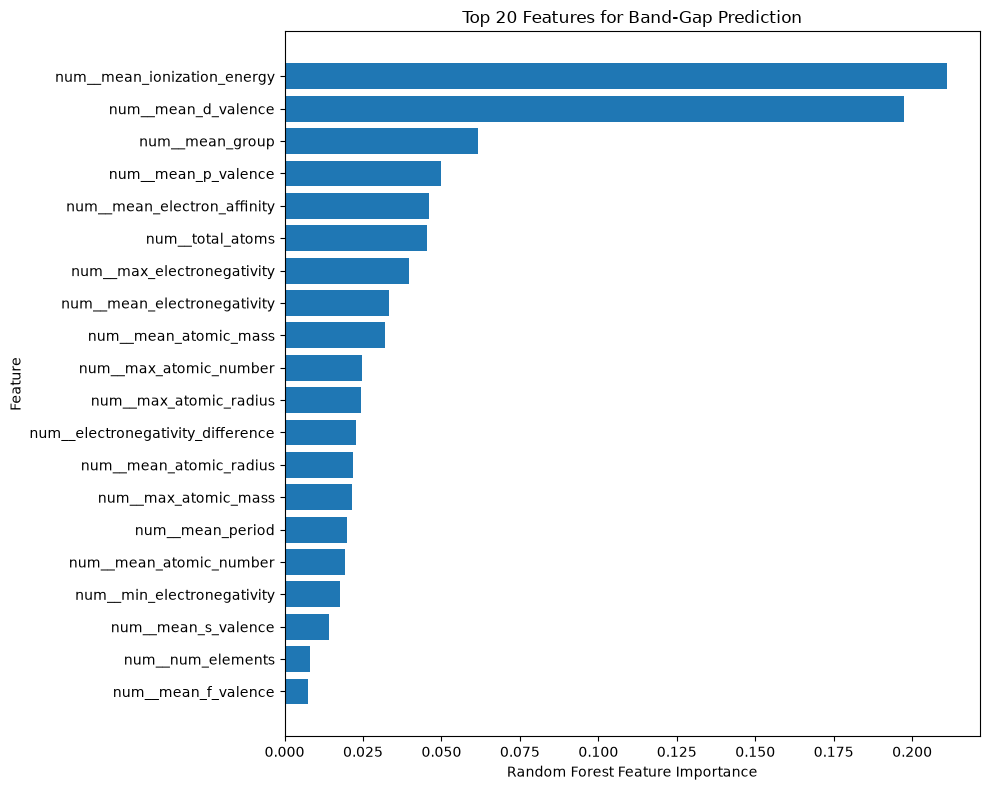

In [138]:
import matplotlib.pyplot as plt

top_features = importance_df.head(20).sort_values(
    "importance"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features for Band-Gap Prediction")

plt.tight_layout()
plt.show()

In [139]:
descriptor_groups = {
    "electronegativity": [
        "mean_electronegativity",
        "min_electronegativity",
        "max_electronegativity",
        "electronegativity_difference"
    ],

    "energy": [
        "mean_ionization_energy",
        "mean_electron_affinity"
    ],

    "valence": [
        "mean_s_valence",
        "mean_p_valence",
        "mean_d_valence",
        "mean_f_valence"
    ],

    "periodic": [
        "mean_period",
        "mean_group"
    ]
}

for name, features in descriptor_groups.items():
    print(name, ":", features)

electronegativity : ['mean_electronegativity', 'min_electronegativity', 'max_electronegativity', 'electronegativity_difference']
energy : ['mean_ionization_energy', 'mean_electron_affinity']
valence : ['mean_s_valence', 'mean_p_valence', 'mean_d_valence', 'mean_f_valence']
periodic : ['mean_period', 'mean_group']


In [140]:
baseline_features = [
    "num_elements",
    "total_atoms",
    "mean_atomic_number",
    "min_atomic_number",
    "max_atomic_number",
    "mean_atomic_mass",
    "min_atomic_mass",
    "max_atomic_mass",
    "mean_atomic_radius",
    "min_atomic_radius",
    "max_atomic_radius",
    "crys",
    "spg_number"
]

test_features = baseline_features + [
    "mean_ionization_energy",
    "mean_d_valence"
]

X_ablation = enhanced_features_df[test_features]

X_ablation_train = X_ablation.loc[X_train.index]
X_ablation_test = X_ablation.loc[X_test.index]

In [141]:
numeric_ablation = [
    f for f in test_features
    if f not in ["crys", "spg_number"]
]

categorical_ablation = [
    "crys",
    "spg_number"
]

preprocessor_ablation = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]),
        numeric_ablation
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_ablation
    )
])

In [142]:
rf_ablation = Pipeline([
    ("preprocessor", preprocessor_ablation),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_ablation.fit(
    X_ablation_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['num_elements','total_atoms','mean_atomic_number',...,'spg_number', 'mean_ionization_energy','mean_d_valence']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automaticall

In [143]:
ablation_pred = rf_ablation.predict(
    X_ablation_test
)

ablation_mae = mean_absolute_error(
    y_test,
    ablation_pred
)

ablation_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ablation_pred
    )
)

ablation_r2 = r2_score(
    y_test,
    ablation_pred
)

print(f"MAE : {ablation_mae:.4f} eV")
print(f"RMSE: {ablation_rmse:.4f} eV")
print(f"R²  : {ablation_r2:.4f}")

MAE : 0.2920 eV
RMSE: 0.6339 eV
R²  : 0.7653


In [144]:
descriptor_groups

{'electronegativity': ['mean_electronegativity',
  'min_electronegativity',
  'max_electronegativity',
  'electronegativity_difference'],
 'energy': ['mean_ionization_energy', 'mean_electron_affinity'],
 'valence': ['mean_s_valence',
  'mean_p_valence',
  'mean_d_valence',
  'mean_f_valence'],
 'periodic': ['mean_period', 'mean_group']}

In [145]:
def run_ablation(feature_list):

    X_data = enhanced_features_df[feature_list]

    X_train_ab = X_data.loc[X_train.index]
    X_test_ab = X_data.loc[X_test.index]

    categorical = [
        f for f in ["crys", "spg_number"]
        if f in feature_list
    ]

    numerical = [
        f for f in feature_list
        if f not in categorical
    ]

    preprocessor = ColumnTransformer([
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numerical
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical
        )
    ])

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(
        X_train_ab,
        y_train
    )

    predictions = model.predict(X_test_ab)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    return mae, rmse, r2

In [146]:
ablation_results = {}

for group_name, group_features in descriptor_groups.items():

    print(f"Running: {group_name}")

    features = baseline_features + group_features

    results = run_ablation(features)

    ablation_results[group_name] = results

    print(
        f"MAE={results[0]:.4f}, "
        f"RMSE={results[1]:.4f}, "
        f"R²={results[2]:.4f}"
    )

Running: electronegativity
MAE=0.3003, RMSE=0.6541, R²=0.7502
Running: energy
MAE=0.3031, RMSE=0.6585, R²=0.7467
Running: valence
MAE=0.2707, RMSE=0.6127, R²=0.7807
Running: periodic
MAE=0.2986, RMSE=0.6502, R²=0.7531


In [147]:
ablation_table = pd.DataFrame(
    ablation_results,
    index=["MAE", "RMSE", "R²"]
).T

print(ablation_table)

                        MAE      RMSE        R²
electronegativity  0.300335  0.654067  0.750154
energy             0.303119  0.658509  0.746749
valence            0.270679  0.612738  0.780730
periodic           0.298638  0.650234  0.753074


In [148]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf_enhanced,
    X_enhanced_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [150]:
perm_df = pd.DataFrame({
    "feature": X_enhanced_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
})

perm_df = perm_df.sort_values(
    "importance_mean",
    ascending=False
)

print(perm_df.head(25).to_string(index=False))


                     feature  importance_mean  importance_std
      mean_ionization_energy         0.269390        0.001759
              mean_p_valence         0.240695        0.002026
              mean_d_valence         0.238375        0.003724
                  mean_group         0.112222        0.001446
       max_electronegativity         0.103928        0.001548
                 total_atoms         0.092889        0.001685
      mean_electron_affinity         0.075575        0.000646
      mean_electronegativity         0.070591        0.000515
           max_atomic_number         0.068976        0.001199
             max_atomic_mass         0.058458        0.000959
            mean_atomic_mass         0.057174        0.000433
           max_atomic_radius         0.055227        0.001322
electronegativity_difference         0.052816        0.000704
                 mean_period         0.049280        0.001044
       min_electronegativity         0.041408        0.000887
        

In [151]:
enhanced_residuals = y_test.values - enhanced_predictions
enhanced_abs_error = np.abs(enhanced_residuals)

print("MAE:", np.mean(enhanced_abs_error))
print("RMSE:", np.sqrt(np.mean(enhanced_residuals**2)))

print("Median absolute error:",
      np.median(enhanced_abs_error))

print("Errors > 1 eV:",
      np.sum(enhanced_abs_error > 1))

print("Errors > 2 eV:",
      np.sum(enhanced_abs_error > 2))

print("Errors > 3 eV:",
      np.sum(enhanced_abs_error > 3))

print("Errors > 5 eV:",
      np.sum(enhanced_abs_error > 5))

MAE: 0.24967815417893952
RMSE: 0.5676359893986475
Median absolute error: 0.025430916666666668
Errors > 1 eV: 1317
Errors > 2 eV: 315
Errors > 3 eV: 105
Errors > 5 eV: 13


In [152]:
zero_mask = y_test.values == 0
nonzero_mask = y_test.values > 0

print(
    "Zero-gap MAE:",
    mean_absolute_error(
        y_test.values[zero_mask],
        enhanced_predictions[zero_mask]
    )
)

print(
    "Non-zero-gap MAE:",
    mean_absolute_error(
        y_test.values[nonzero_mask],
        enhanced_predictions[nonzero_mask]
    )
)

Zero-gap MAE: 0.1224443694080962
Non-zero-gap MAE: 0.5675967002168162


In [153]:
bins = [-0.001, 0, 1, 2, 3, 5, 10, np.inf]

labels = [
    "0 eV",
    "0–1 eV",
    "1–2 eV",
    "2–3 eV",
    "3–5 eV",
    "5–10 eV",
    ">10 eV"
]

gap_bins = pd.cut(
    y_test.values,
    bins=bins,
    labels=labels
)

error_by_gap = []

for label in labels:

    mask = gap_bins == label

    if mask.sum() == 0:
        continue

    mae = mean_absolute_error(
        y_test.values[mask],
        enhanced_predictions[mask]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test.values[mask],
            enhanced_predictions[mask]
        )
    )

    error_by_gap.append({
        "gap_range": label,
        "count": mask.sum(),
        "MAE": mae,
        "RMSE": rmse
    })

error_by_gap_df = pd.DataFrame(error_by_gap)

print(error_by_gap_df)

  gap_range  count       MAE      RMSE
0      0 eV  13413  0.122444  0.387993
1    0–1 eV   1996  0.346002  0.619776
2    1–2 eV   1107  0.480701  0.645361
3    2–3 eV    850  0.669789  0.883079
4    3–5 eV   1031  0.853272  1.160484
5   5–10 eV    383  0.978371  1.402212
6    >10 eV      1  0.342995  0.342995


In [158]:
# Enhanced feature columns
numeric_features_enhanced = [
    "num_elements",
    "total_atoms",
    "mean_atomic_number",
    "min_atomic_number",
    "max_atomic_number",
    "mean_atomic_mass",
    "min_atomic_mass",
    "max_atomic_mass",
    "mean_atomic_radius",
    "min_atomic_radius",
    "max_atomic_radius",

    # New descriptors
    "mean_electronegativity",
    "min_electronegativity",
    "max_electronegativity",
    "electronegativity_difference",
    "mean_ionization_energy",
    "mean_electron_affinity",
    "mean_s_valence",
    "mean_p_valence",
    "mean_d_valence",
    "mean_f_valence",
    "mean_period",
    "mean_group",
]

categorical_features_enhanced = [
    "crys",
    "spg_number"
]

print("Numeric features:", len(numeric_features_enhanced))
print("Categorical features:", len(categorical_features_enhanced))
print("Total:", len(numeric_features_enhanced) + len(categorical_features_enhanced))

Numeric features: 23
Categorical features: 2
Total: 25


In [159]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

def create_enhanced_preprocessor():

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", numeric_transformer, numeric_features_enhanced),
        ("cat", categorical_transformer, categorical_features_enhanced)
    ])

In [160]:
print("X_enhanced:", X_enhanced.shape)

preprocessor_test = create_enhanced_preprocessor()

X_transformed_test = preprocessor_test.fit_transform(X_enhanced)

print("Transformed shape:", X_transformed_test.shape)

X_enhanced: (93902, 25)
Transformed shape: (93902, 245)


In [161]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

enhanced_cv_model = Pipeline([
    ("preprocessor", create_enhanced_preprocessor()),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

cv_results_enhanced = cross_validate(
    enhanced_cv_model,
    X_enhanced,
    y_enhanced,
    cv=cv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=1,
    return_train_score=False
)

mae_scores = -cv_results_enhanced["test_mae"]
rmse_scores = -cv_results_enhanced["test_rmse"]
r2_scores = cv_results_enhanced["test_r2"]

print("Enhanced Random Forest — 5-Fold Cross-Validation")
print("-" * 60)

print(f"MAE :  {mae_scores.mean():.4f} ± {mae_scores.std():.4f} eV")
print(f"RMSE:  {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f} eV")
print(f"R²  :  {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

print("\nIndividual fold results:")

for i in range(5):
    print(
        f"Fold {i+1}: "
        f"MAE={mae_scores[i]:.4f}, "
        f"RMSE={rmse_scores[i]:.4f}, "
        f"R²={r2_scores[i]:.4f}"
    )

Enhanced Random Forest — 5-Fold Cross-Validation
------------------------------------------------------------
MAE :  0.2464 ± 0.0032 eV
RMSE:  0.5557 ± 0.0115 eV
R²  :  0.8202 ± 0.0057

Individual fold results:
Fold 1: MAE=0.2506, RMSE=0.5713, R²=0.8180
Fold 2: MAE=0.2487, RMSE=0.5673, R²=0.8117
Fold 3: MAE=0.2472, RMSE=0.5503, R²=0.8197
Fold 4: MAE=0.2429, RMSE=0.5478, R²=0.8221
Fold 5: MAE=0.2424, RMSE=0.5417, R²=0.8294


In [162]:
# ============================================================
# SAVE ENHANCED DATASET FOR NEXT NOTEBOOK
# ============================================================

from pathlib import Path

# Create data directory if it doesn't exist
Path("../data").mkdir(parents=True, exist_ok=True)

# Save enhanced descriptors + target
enhanced_features_df.to_csv(
    "../data/enhanced_material_descriptors.csv",
    index=False
)

print("Saved enhanced dataset successfully.")
print("Shape:", enhanced_features_df.shape)
print("File: ../data/enhanced_material_descriptors.csv")

Saved enhanced dataset successfully.
Shape: (93902, 26)
File: ../data/enhanced_material_descriptors.csv
